In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.metrics import mean_squared_error, mean_absolute_error
import pmdarima as pm

In [2]:
# Download stock data
data = yf.download("IBM", start="2020-01-01", end="2025-10-12")

[*********************100%***********************]  1 of 1 completed


In [3]:
# Data cleaning
data['Adj Close'] = data['Close'].ffill()

In [4]:
# Split into training and test sets
train_size_ratio = 0.9
train_size = int(len(data) * train_size_ratio)
train, test = data['Adj Close'][:train_size], data['Adj Close'][train_size:]

print(f"Training samples: {len(train)}, Test samples: {len(test)}")

Training samples: 1306, Test samples: 146


In [5]:
# ===============================
# Step 1: Fit initial model on training data
# ===============================
model = pm.auto_arima(
    train,
    start_p=0, max_p=6,
    start_q=0, max_q=6,
    d=None,                 # Automatically selects differencing order
    seasonal=False,
    stepwise=True,
    suppress_warnings=True,
    trace=True,
    information_criterion='aic'
)

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=5746.125, Time=0.21 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=5748.045, Time=0.54 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=5748.052, Time=0.63 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=5747.242, Time=0.15 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=5749.633, Time=2.21 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0] intercept
Total fit time: 3.778 seconds


In [6]:
print("\n=== Model Summary ===")
print(model.summary())


=== Model Summary ===
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1306
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -2871.062
Date:                Sat, 06 Jun 2026   AIC                           5746.125
Time:                        14:43:03   BIC                           5756.473
Sample:                             0   HQIC                          5750.007
                               - 1306                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.1068      0.062      1.718      0.086      -0.015       0.229
sigma2         4.7694      0.049     97.243      0.000       4.673       4.866
Ljung-Box (L1) (Q):          

In [7]:
# ===============================
# Step 2: Recursive one-step-ahead forecasting
# ===============================
history = list(train)
predictions = []

for t in range(len(test)):
    # Fit ARIMA model on current history
    model_fit = pm.ARIMA(order=model.order)
    model_fit.fit(history)

    # Forecast one step ahead
    forecast = model_fit.predict(n_periods=1)[0]
    predictions.append(forecast)

    # Update history with actual observed value
    history.append(test.iloc[t])

In [8]:
# ===============================
# Step 3: Model evaluation
# ===============================
mse = mean_squared_error(test, predictions)
mae = mean_absolute_error(test, predictions)

print("\nRecursive Forecast Evaluation:")
print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")


Recursive Forecast Evaluation:
MSE: 20.6028
MAE: 3.2703


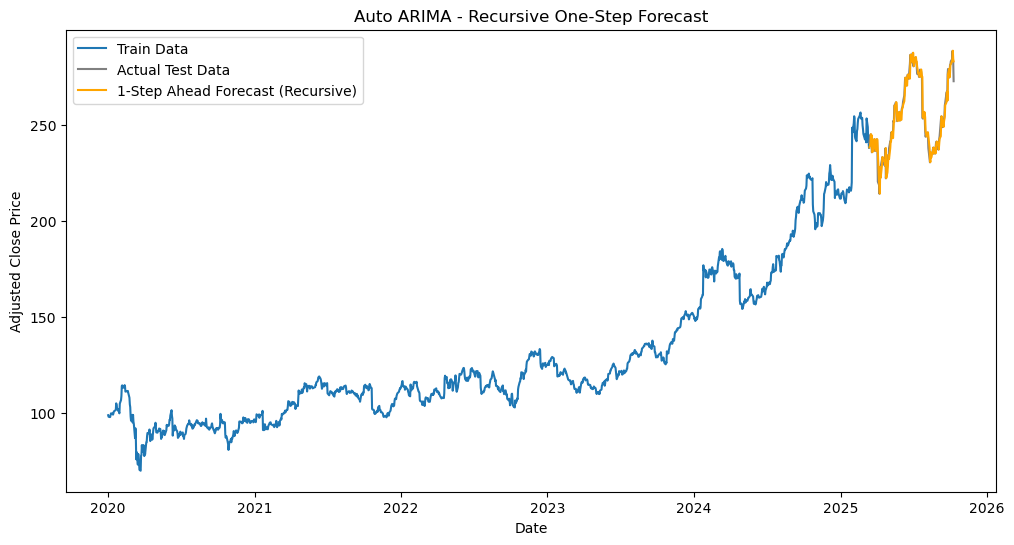

In [9]:
# ===============================
# Step 4: Plot results
# ===============================
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label='Train Data')
plt.plot(test.index, test, label='Actual Test Data', color='gray')
plt.plot(test.index, predictions, label='1-Step Ahead Forecast (Recursive)', color='orange')

plt.title("Auto ARIMA - Recursive One-Step Forecast")
plt.xlabel("Date")
plt.ylabel("Adjusted Close Price")
plt.legend()
plt.show()

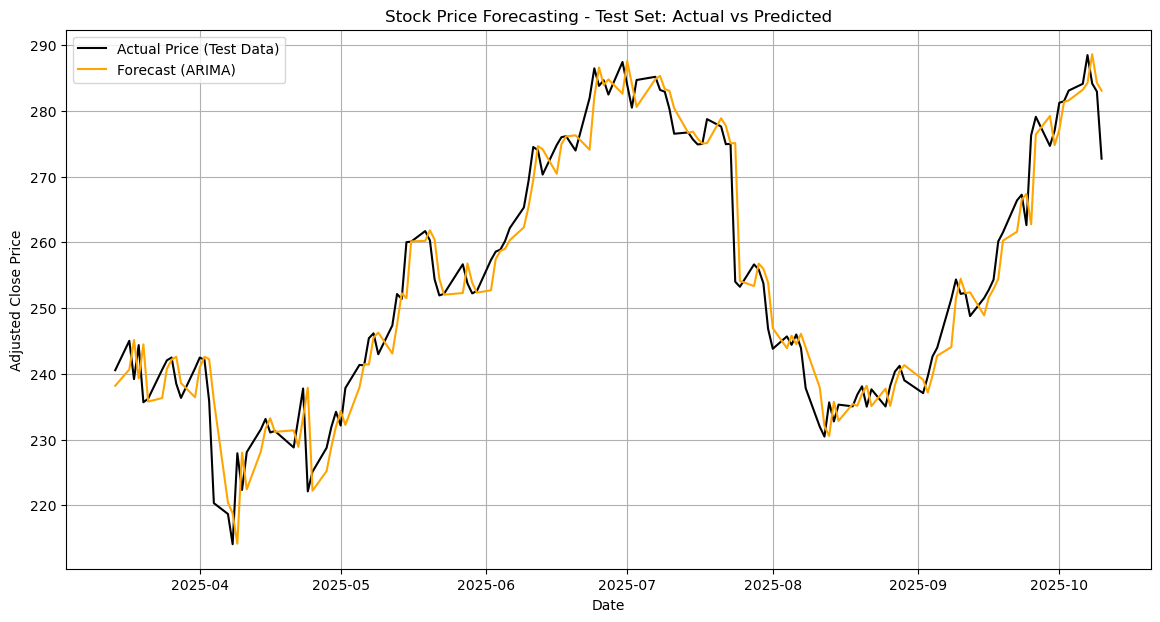

In [10]:
# ===============================
# Test Set Visualization: Actual vs Forecast
# ===============================

plt.figure(figsize=(14, 7))

# Actual test data
plt.plot(test.index, test, label='Actual Price (Test Data)', color='black')

# Predicted values
plt.plot(test.index, predictions, label='Forecast (ARIMA)', color='orange')

plt.title("Stock Price Forecasting - Test Set: Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("Adjusted Close Price")

plt.legend()
plt.grid(True)
plt.show()

C:\Users\2023\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\2023\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


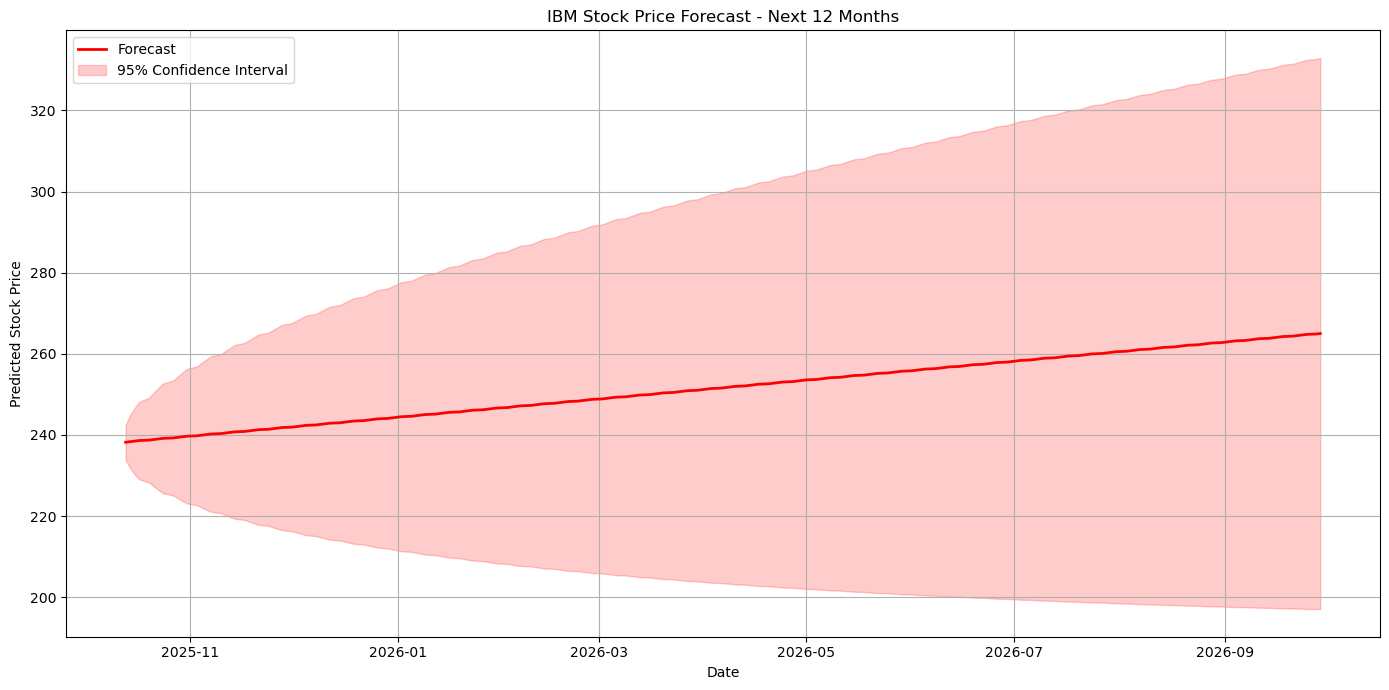

In [16]:
# ===============================
# Future Forecast (12 Months Ahead)
# ===============================

future_steps = 252  # approximately 1 trading year

# Generate future forecast
future_pred, future_conf = model.predict(
    n_periods=future_steps,
    return_conf_int=True
)

# Create future trading dates
future_dates = pd.bdate_range(
    start=data.index[-1] + pd.Timedelta(days=1),
    periods=future_steps
)

# Plot future forecast only
plt.figure(figsize=(14, 7))

plt.plot(
    future_dates,
    future_pred,
    color='red',
    linewidth=2,
    label='Forecast'
)

plt.fill_between(
    future_dates,
    future_conf[:, 0],
    future_conf[:, 1],
    color='red',
    alpha=0.2,
    label='95% Confidence Interval'
)

plt.title("IBM Stock Price Forecast - Next 12 Months")
plt.xlabel("Date")
plt.ylabel("Predicted Stock Price")

plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()